<a href="https://colab.research.google.com/github/RifaDeen/symAD-ECNN/blob/main/notebooks/models/06_resnet_finetuned.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 ResNet-Autoencoder (Fine-tuned) for Brain MRI Anomaly Detection

## 📋 Overview

This notebook implements a **fine-tuned ResNet-18 Autoencoder** that adapts pretrained ImageNet features to medical images.

### Model Architecture
- **Encoder**: ResNet-18 (pretrained on ImageNet, **fine-tuned**)
- **Latent**: 512-dimensional features from ResNet
- **Decoder**: Trainable CNN decoder for pixel reconstruction
- **Training**: Both encoder and decoder are trained

### Key Differences from Frozen ResNet-AE
- ✅ **ResNet layers are trainable** - adapts to MRI domain
- ✅ **Two fine-tuning strategies** - partial (layer4 only) or full
- ⏱️ **Longer training** - ~40-50 min vs 20 min for frozen
- 📈 **Better performance** - expected +0.02-0.05 AUROC improvement

### Expected Performance
- **AUROC**: ~0.80-0.88 (better than frozen baseline)
- **Training Time**: ~40-50 min (full model training)

### Research Question
> "Does fine-tuning pretrained features to the medical domain improve anomaly detection?"

---

## 1️⃣ Setup and Environment Configuration

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

print("✅ Google Drive mounted successfully!")

Mounted at /content/drive
✅ Google Drive mounted successfully!


In [2]:
# Keep Colab session alive
import IPython
from google.colab import output

display(IPython.display.Javascript('''
 function ClickConnect(){
   btn = document.querySelector("colab-connect-button");
   if (btn != null){
     console.log("Click colab-connect-button");
     btn.click();
   }
   btn = document.querySelector('#ok');
   if (btn != null){
     console.log("Click connect button");
     btn.click();
   }
 }
 setInterval(ClickConnect, 60000)
'''))

print("✅ Keep-alive script activated!")

<IPython.core.display.Javascript object>

✅ Keep-alive script activated!


## ⚡ Turbo Data Loading (Local Disk)

**Why this matters**: Loading 33k+ files from Google Drive is SLOW (~30 min). Instead:
1. **Check** if zip files exist (created once)
2. **Extract** to local runtime disk (~2 min)
3. **Train** with blazing fast I/O (10-20x speedup)

**Note**: If this is your first run, the zip files already exist from CNN-AE training.

In [3]:
import os
from google.colab import drive

# Check for the zips
base = "/content/drive/MyDrive/symAD-ECNN/data"
zips = [f"{base}/train_fast.zip", f"{base}/val_fast.zip", f"{base}/test_fast.zip"]

missing = [f for f in zips if not os.path.exists(f)]

if len(missing) == 0:
    print("✅ GOOD NEWS: Zip files found! Proceeding to extraction...")
else:
    print("⚠️ WARNING: Zip files missing. Please run the CNN-AE notebook first to create them.")
    print(f"   Missing: {missing}")

✅ GOOD NEWS: Zip files found! Proceeding to extraction...


In [4]:
# ==========================================
# ⚡ TURBO LOADER (Unzip to Local)
# ==========================================
import zipfile
import os
import shutil

BASE_DIR = "/content/drive/MyDrive/symAD-ECNN/data"
LOCAL_DIR = "/content/local_data"

ZIPS = {
    "train": f"{BASE_DIR}/train_fast.zip",
    "val":   f"{BASE_DIR}/val_fast.zip",
    "test":  f"{BASE_DIR}/test_fast.zip"
}

print("🚀 Extracting to Local Disk...")

for name, zip_path in ZIPS.items():
    target_dir = f"{LOCAL_DIR}/{name}"
    # Clean up old run if exists
    if os.path.exists(target_dir):
        shutil.rmtree(target_dir)
    os.makedirs(target_dir, exist_ok=True)

    if os.path.exists(zip_path):
        print(f"   📂 Unzipping {name}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(target_dir)
    else:
        print(f"   ❌ ERROR: {zip_path} not found!")

print("\n✅ Data Ready! Local folders created.")

🚀 Extracting to Local Disk...
   📂 Unzipping train...
   📂 Unzipping val...
   📂 Unzipping test...

✅ Data Ready! Local folders created.


In [5]:
# Install required packages
!pip install pytorch-msssim -q

print("✅ All packages installed!")

✅ All packages installed!


In [6]:
# Import libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.cuda.amp import autocast, GradScaler
from pytorch_msssim import SSIM

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc, confusion_matrix
from glob import glob
import os
import time
from tqdm import tqdm
import json

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.backends.cudnn.deterministic = True

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [7]:
# Setup device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Using device: {device}")

if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

🚀 Using device: cuda
   GPU: Tesla T4
   Memory: 15.83 GB


In [8]:
# ============================================
# 🎛️ FINE-TUNING CONFIGURATION
# ============================================

# Choose fine-tuning strategy:
# 'partial' - Only fine-tune layer4 (last ResNet block) - RECOMMENDED
# 'full'    - Fine-tune entire ResNet (all layers)
# 'none'    - No fine-tuning (same as 04_resnet_autoencoder.ipynb)

FINETUNE_STRATEGY = 'partial'  # Change to 'full' for complete fine-tuning

print(f"🎛️ Fine-tuning Strategy: {FINETUNE_STRATEGY.upper()}")
if FINETUNE_STRATEGY == 'partial':
    print("   → Will fine-tune ResNet layer4 (last block) + decoder")
    print("   → Faster training, less risk of overfitting")
elif FINETUNE_STRATEGY == 'full':
    print("   → Will fine-tune entire ResNet + decoder")
    print("   → Maximum adaptation to MRI domain")
else:
    print("   → No fine-tuning (frozen encoder)")

🎛️ Fine-tuning Strategy: PARTIAL
   → Will fine-tune ResNet layer4 (last block) + decoder
   → Faster training, less risk of overfitting


In [9]:
# Define paths
BASE_PATH = "/content/drive/MyDrive/symAD-ECNN"

# ⚡ DATA PATHS (Point to LOCAL DISK for speed) ⚡
IXI_TRAIN_PATH = "/content/local_data/train"
IXI_VAL_PATH   = "/content/local_data/val"
BRATS_PATH     = "/content/local_data/test"

# Model and results paths (separate folder for fine-tuned model) (Keep on Drive!)
MODEL_PATH = f"{BASE_PATH}/models/saved_models/resnet_finetuned_{FINETUNE_STRATEGY}"
RESULTS_PATH = f"{BASE_PATH}/results/resnet_finetuned_{FINETUNE_STRATEGY}"

# Create directories
os.makedirs(MODEL_PATH, exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)

print("📁 Paths configured:")
print(f"   ⚡ Data (Local): {IXI_TRAIN_PATH}")
print(f"   💾 Models (Drive): {MODEL_PATH}")
print(f"   📊 Results (Drive): {RESULTS_PATH}")

📁 Paths configured:
   ⚡ Data (Local): /content/local_data/train
   💾 Models (Drive): /content/drive/MyDrive/symAD-ECNN/models/saved_models/resnet_finetuned_partial
   📊 Results (Drive): /content/drive/MyDrive/symAD-ECNN/results/resnet_finetuned_partial


## 2️⃣ Data Loading

In [10]:
# Dataset class
class MRIDataset(Dataset):
    """
    Dataset for MRI slices.
    Returns both grayscale (for output) and RGB (for ResNet encoder).
    """
    def __init__(self, file_list):
        self.files = file_list
        # Transform for ResNet encoder (RGB, 224x224, normalized)
        self.resnet_transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        try:
            # Load grayscale image (128x128)
            img = np.load(self.files[idx])

            # Target: grayscale (1, 128, 128)
            target = torch.from_numpy(np.expand_dims(img, 0)).float()

            # Input: convert to RGB for ResNet
            img_uint8 = (img * 255).astype(np.uint8)
            img_rgb = np.stack([img_uint8, img_uint8, img_uint8], axis=-1)
            input_tensor = self.resnet_transform(img_rgb)

            return input_tensor, target
        except Exception as e:
            print(f"Error loading {self.files[idx]}: {e}")
            return torch.zeros((3, 224, 224)), torch.zeros((1, 128, 128))

print("✅ Dataset class defined!")

✅ Dataset class defined!


In [11]:
# Load file paths
print("📂 Loading file paths...")

train_files = sorted(glob(f"{IXI_TRAIN_PATH}/*.npy"))
val_files = sorted(glob(f"{IXI_VAL_PATH}/*.npy"))
brats_files = sorted(glob(f"{BRATS_PATH}/*.npy"))

if len(train_files) == 0:
    raise ValueError(f"❌ No training files found!")

print(f"✅ Found {len(train_files):,} IXI training slices")
print(f"✅ Found {len(val_files):,} IXI validation slices")
print(f"✅ Found {len(brats_files):,} BraTS test slices")

📂 Loading file paths...
✅ Found 33,078 IXI training slices
✅ Found 3,652 IXI validation slices
✅ Found 7,794 BraTS test slices


In [12]:
# Create datasets and dataloaders
BATCH_SIZE = 64

train_dataset = MRIDataset(train_files)
val_dataset = MRIDataset(val_files)
test_dataset = MRIDataset(brats_files)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"✅ DataLoaders created!")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

✅ DataLoaders created!
   Batch size: 64
   Train batches: 517
   Val batches: 58
   Test batches: 122


## 3️⃣ ResNet-Autoencoder Architecture (Fine-tunable)

In [13]:
class ResNetAutoencoder(nn.Module):
    """
    ResNet-Autoencoder with configurable fine-tuning.

    Args:
        finetune_strategy: 'none', 'partial', or 'full'
    """
    def __init__(self, finetune_strategy='partial'):
        super(ResNetAutoencoder, self).__init__()
        self.finetune_strategy = finetune_strategy

        # ENCODER: Pretrained ResNet-18
        resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        # Extract layers
        self.encoder = nn.Sequential(*list(resnet.children())[:-1])  # Output: (512, 1, 1)

        # Configure fine-tuning
        if finetune_strategy == 'none':
            # Freeze entire encoder
            for param in self.encoder.parameters():
                param.requires_grad = False

        elif finetune_strategy == 'partial':
            # Freeze early layers, fine-tune layer4 only
            for i, module in enumerate(self.encoder.children()):
                if i < 7:  # Freeze conv1, bn1, relu, maxpool, layer1, layer2, layer3
                    for param in module.parameters():
                        param.requires_grad = False
                else:  # Fine-tune layer4 and avgpool
                    for param in module.parameters():
                        param.requires_grad = True

        elif finetune_strategy == 'full':
            # Unfreeze entire encoder
            for param in self.encoder.parameters():
                param.requires_grad = True

        # DECODER: Trainable upsampling network
        self.decoder = nn.Sequential(
            # 512 x 1 x 1 -> 512 x 4 x 4
            nn.ConvTranspose2d(512, 512, kernel_size=4, stride=1, padding=0),
            nn.BatchNorm2d(512),
            nn.ReLU(True),

            # 512 x 4 x 4 -> 256 x 8 x 8
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # 256 x 8 x 8 -> 128 x 16 x 16
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # 128 x 16 x 16 -> 64 x 32 x 32
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            # 64 x 32 x 32 -> 32 x 64 x 64
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            # 32 x 64 x 64 -> 1 x 128 x 128
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Encode
        features = self.encoder(x)

        # Decode
        reconstruction = self.decoder(features)

        return reconstruction

# Create model with specified fine-tuning strategy
model = ResNetAutoencoder(finetune_strategy=FINETUNE_STRATEGY).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
encoder_trainable = sum(p.numel() for p in model.encoder.parameters() if p.requires_grad)
decoder_trainable = sum(p.numel() for p in model.decoder.parameters() if p.requires_grad)

print("🔬 ResNet-Autoencoder Created!")
print(f"   Fine-tuning Strategy: {FINETUNE_STRATEGY.upper()}")
print(f"\n📊 Parameter Breakdown:")
print(f"   Total parameters:     {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,} ({100 * trainable_params / total_params:.1f}%)")
print(f"   └─ Encoder trainable: {encoder_trainable:,}")
print(f"   └─ Decoder trainable: {decoder_trainable:,}")
print(f"   Frozen parameters:    {total_params - trainable_params:,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 168MB/s]


🔬 ResNet-Autoencoder Created!
   Fine-tuning Strategy: PARTIAL

📊 Parameter Breakdown:
   Total parameters:     18,159,585
   Trainable parameters: 15,376,801 (84.7%)
   └─ Encoder trainable: 8,393,728
   └─ Decoder trainable: 6,983,073
   Frozen parameters:    2,782,784


## 4️⃣ Loss Function and Optimizer

In [14]:
class CombinedLoss(nn.Module):
    """
    Combined MSE + SSIM Loss (same as CNN-AE baseline)
    """
    def __init__(self, alpha=0.84):
        super(CombinedLoss, self).__init__()
        self.alpha = alpha
        self.mse = nn.MSELoss()
        self.ssim = SSIM(data_range=1.0, size_average=True, channel=1, win_size=11)

    def forward(self, output, target):
        mse_loss = self.mse(output, target)
        ssim_loss = 1 - self.ssim(output, target)
        return self.alpha * mse_loss + (1 - self.alpha) * ssim_loss

criterion = CombinedLoss(alpha=0.84)

print("✅ Combined Loss Function created!")
print(f"   MSE weight: 0.84, SSIM weight: 0.16")

✅ Combined Loss Function created!
   MSE weight: 0.84, SSIM weight: 0.16


In [15]:
# Optimizer with different learning rates for encoder and decoder
if FINETUNE_STRATEGY in ['partial', 'full']:
    # Use lower learning rate for pretrained encoder, higher for decoder
    optimizer = optim.Adam([
        {'params': filter(lambda p: p.requires_grad, model.encoder.parameters()), 'lr': 1e-4},  # Encoder: slower
        {'params': model.decoder.parameters(), 'lr': 1e-3}  # Decoder: faster
    ], weight_decay=1e-5)
    print("✅ Optimizer created with differential learning rates:")
    print(f"   Encoder LR: 1e-4 (fine-tuning)")
    print(f"   Decoder LR: 1e-3 (training from scratch)")
else:
    # Only decoder is trainable
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                           lr=1e-3, weight_decay=1e-5)
    print("✅ Optimizer created (decoder only)")

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)
scaler = GradScaler()

print(f"   Optimizing {trainable_params:,} parameters")

✅ Optimizer created with differential learning rates:
   Encoder LR: 1e-4 (fine-tuning)
   Decoder LR: 1e-3 (training from scratch)
   Optimizing 15,376,801 parameters


/tmp/ipython-input-1052137928.py:18: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


## 5️⃣ Training Functions

In [16]:
def train_epoch(model, dataloader, criterion, optimizer, device, scaler):
    """Train one epoch with mixed precision"""
    model.train()
    running_loss = 0.0
    pbar = tqdm(dataloader, desc='Training')

    for data, target in pbar:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()

        with autocast():
            output = model(data)
            loss = criterion(output, target)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.6f}'})

    return running_loss / len(dataloader)

def validate(model, dataloader, criterion, device):
    """Validate"""
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        pbar = tqdm(dataloader, desc='Validation')
        for data, target in pbar:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            running_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.6f}'})

    return running_loss / len(dataloader)

print("✅ Training functions defined!")

✅ Training functions defined!


## 6️⃣ Training Loop

In [17]:
# Check for existing checkpoints
checkpoints = sorted(glob(f'{MODEL_PATH}/resnet_epoch*.pth'))
RESUME = len(checkpoints) > 0

if RESUME:
    latest = checkpoints[-1]
    print(f"✅ Found checkpoint: {os.path.basename(latest)}")
    checkpoint = torch.load(latest, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    if 'scheduler_state_dict' in checkpoint:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch']
    train_losses = checkpoint.get('train_losses', [])
    val_losses = checkpoint.get('val_losses', [])
    best_val_loss = checkpoint.get('best_val_loss', float('inf'))
    best_epoch = checkpoint.get('best_epoch', 0)
    print(f"   Resuming from epoch {start_epoch}")
else:
    start_epoch = 0
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_epoch = 0
    print("📝 Starting fresh training")

📝 Starting fresh training


In [18]:
# Training configuration
# More epochs for fine-tuning (needs more time to adapt)
NUM_EPOCHS = 40 if FINETUNE_STRATEGY in ['partial', 'full'] else 30
KEEP_LAST_N_CHECKPOINTS = 3

print(f"🚀 Training ResNet-AE ({FINETUNE_STRATEGY}): Epochs {start_epoch + 1} to {NUM_EPOCHS}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Device: {device}")
print(f"   Fine-tuning: {FINETUNE_STRATEGY.upper()}")
print(f"   Training params: {trainable_params:,}")
print("-" * 60)

start_time = time.time()

for epoch in range(start_epoch, NUM_EPOCHS):
    epoch_start = time.time()

    train_loss = train_epoch(model, train_loader, criterion, optimizer, device, scaler)
    val_loss = validate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    epoch_time = time.time() - epoch_start
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch [{epoch+1:3d}/{NUM_EPOCHS}] | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {current_lr:.2e} | Time: {epoch_time/60:.1f}min")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_losses': train_losses,
            'val_losses': val_losses,
            'best_val_loss': best_val_loss,
            'best_epoch': best_epoch,
            'finetune_strategy': FINETUNE_STRATEGY
        }, f'{MODEL_PATH}/resnet_best.pth')
        print(f"   ✅ Best model saved!")

    # Save checkpoint
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'best_val_loss': best_val_loss,
        'best_epoch': best_epoch,
        'finetune_strategy': FINETUNE_STRATEGY
    }, f'{MODEL_PATH}/resnet_epoch{epoch+1}.pth')

    # Cleanup old checkpoints
    checkpoints = sorted(glob(f'{MODEL_PATH}/resnet_epoch*.pth'))
    if len(checkpoints) > KEEP_LAST_N_CHECKPOINTS:
        for old_ckpt in checkpoints[:-KEEP_LAST_N_CHECKPOINTS]:
            os.remove(old_ckpt)
            print(f"   🗑️ Deleted old checkpoint: {os.path.basename(old_ckpt)}")

    print("-" * 60)

total_time = time.time() - start_time
print(f"\n🎉 Training Complete!")
print(f"   Total Time: {total_time/3600:.2f} hours")
print(f"   Best Epoch: {best_epoch}, Best Val Loss: {best_val_loss:.6f}")

🚀 Training ResNet-AE (partial): Epochs 1 to 40
   Batch size: 64
   Device: cuda
   Fine-tuning: PARTIAL
   Training params: 15,376,801
------------------------------------------------------------


Training:   0%|          | 0/517 [00:00<?, ?it/s]/tmp/ipython-input-3114230733.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Training:  87%|████████▋ | 449/517 [01:27<00:10,  6.49it/s, loss=0.061583]

Error loading /content/local_data/train/IXI016-Guys-0697-T1_slice_166.npy: No data left in file


Validation: 100%|██████████| 58/58 [00:10<00:00,  5.37it/s, loss=0.088777]


Epoch [  1/40] | Train: 0.081543 | Val: 0.106300 | LR: 1.00e-04 | Time: 1.8min
   ✅ Best model saved!
------------------------------------------------------------


...

Epoch [ 39/40] | Train: 0.047961 | Val: 0.043122 | LR: 5.00e-05 | Time: 1.5min
   🗑️ Deleted old checkpoint: resnet_epoch39.pth
------------------------------------------------------------


Training:  68%|██████▊   | 351/517 [00:54<00:23,  7.05it/s, loss=0.045468]

Error loading /content/local_data/train/IXI016-Guys-0697-T1_slice_166.npy: No data left in file


Validation: 100%|██████████| 58/58 [00:09<00:00,  6.32it/s, loss=0.048431]


Epoch [ 40/40] | Train: 0.045882 | Val: 0.050886 | LR: 5.00e-05 | Time: 1.5min
   🗑️ Deleted old checkpoint: resnet_epoch40.pth
------------------------------------------------------------

🎉 Training Complete!
   Total Time: 1.01 hours
   Best Epoch: 38, Best Val Loss: 0.043106


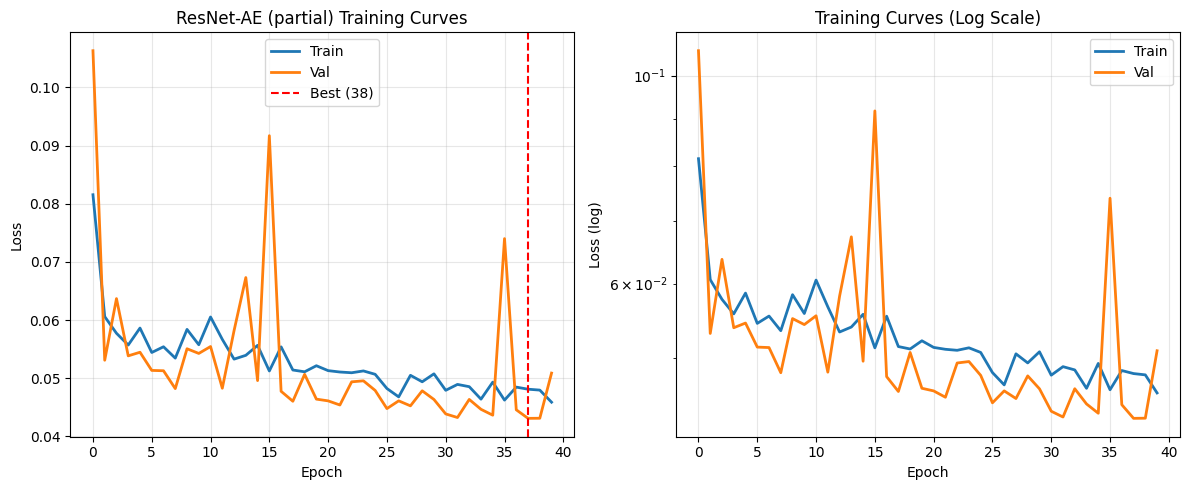

In [19]:
# Plot training curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train', linewidth=2)
plt.plot(val_losses, label='Val', linewidth=2)
plt.axvline(x=best_epoch-1, color='r', linestyle='--', label=f'Best ({best_epoch})')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'ResNet-AE ({FINETUNE_STRATEGY}) Training Curves')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(train_losses, label='Train', linewidth=2)
plt.plot(val_losses, label='Val', linewidth=2)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss (log)')
plt.title('Training Curves (Log Scale)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/resnet_finetuned_training_curves.png', dpi=150)
plt.show()

## 7️⃣ Evaluation

In [20]:
# Load best model
checkpoint = torch.load(f'{MODEL_PATH}/resnet_best.pth')
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"✅ Best model loaded (Epoch {checkpoint['epoch']}, Val Loss: {checkpoint['val_loss']:.6f})")

# Calculate reconstruction errors
def calculate_errors(model, dataloader, device):
    model.eval()
    errors = []
    with torch.no_grad():
        for data, target in tqdm(dataloader, desc='Computing errors'):
            data, target = data.to(device), target.to(device)
            recon = model(data)
            mse = nn.functional.mse_loss(recon, target, reduction='none').view(data.size(0), -1).mean(dim=1)
            errors.extend(mse.cpu().numpy())
    return np.array(errors)

normal_errors = calculate_errors(model, val_loader, device)
anomaly_errors = calculate_errors(model, test_loader, device)

# Metrics
y_true = np.concatenate([np.zeros(len(normal_errors)), np.ones(len(anomaly_errors))])
y_scores = np.concatenate([normal_errors, anomaly_errors])
auroc = roc_auc_score(y_true, y_scores)
precision, recall, _ = precision_recall_curve(y_true, y_scores)
auprc = auc(recall, precision)

print(f"\n📈 ResNet-AE ({FINETUNE_STRATEGY}) Performance:")
print(f"   AUROC: {auroc:.4f}")
print(f"   AUPRC: {auprc:.4f}")
print(f"   Normal errors: {normal_errors.mean():.6f} ± {normal_errors.std():.6f}")
print(f"   Anomaly errors: {anomaly_errors.mean():.6f} ± {anomaly_errors.std():.6f}")

✅ Best model loaded (Epoch 38, Val Loss: 0.043106)


Computing errors: 100%|██████████| 122/122 [00:21<00:00,  5.56it/s]


📈 ResNet-AE (partial) Performance:
   AUROC: 0.7398
   AUPRC: 0.8355
   Normal errors: 0.006519 ± 0.002985
   Anomaly errors: 0.009301 ± 0.003968


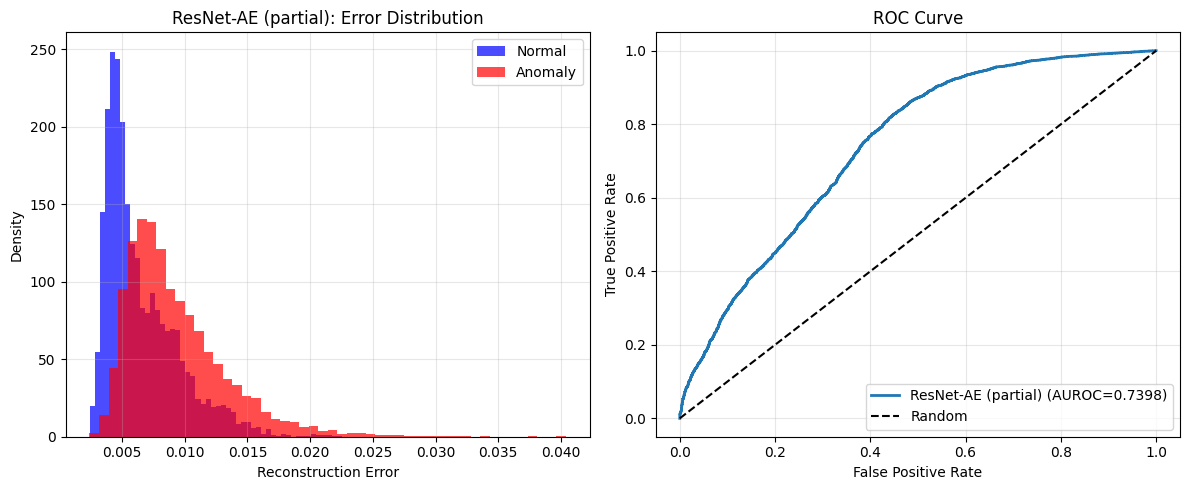

In [21]:
# Plot evaluation results
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(normal_errors, bins=50, alpha=0.7, label='Normal', density=True, color='blue')
plt.hist(anomaly_errors, bins=50, alpha=0.7, label='Anomaly', density=True, color='red')
plt.xlabel('Reconstruction Error')
plt.ylabel('Density')
plt.legend()
plt.title(f'ResNet-AE ({FINETUNE_STRATEGY}): Error Distribution')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_true, y_scores)
plt.plot(fpr, tpr, linewidth=2, label=f'ResNet-AE ({FINETUNE_STRATEGY}) (AUROC={auroc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.title('ROC Curve')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/resnet_finetuned_evaluation.png', dpi=150)
plt.show()

🌟 Visualizing Top 5 Best Healthy Brains...


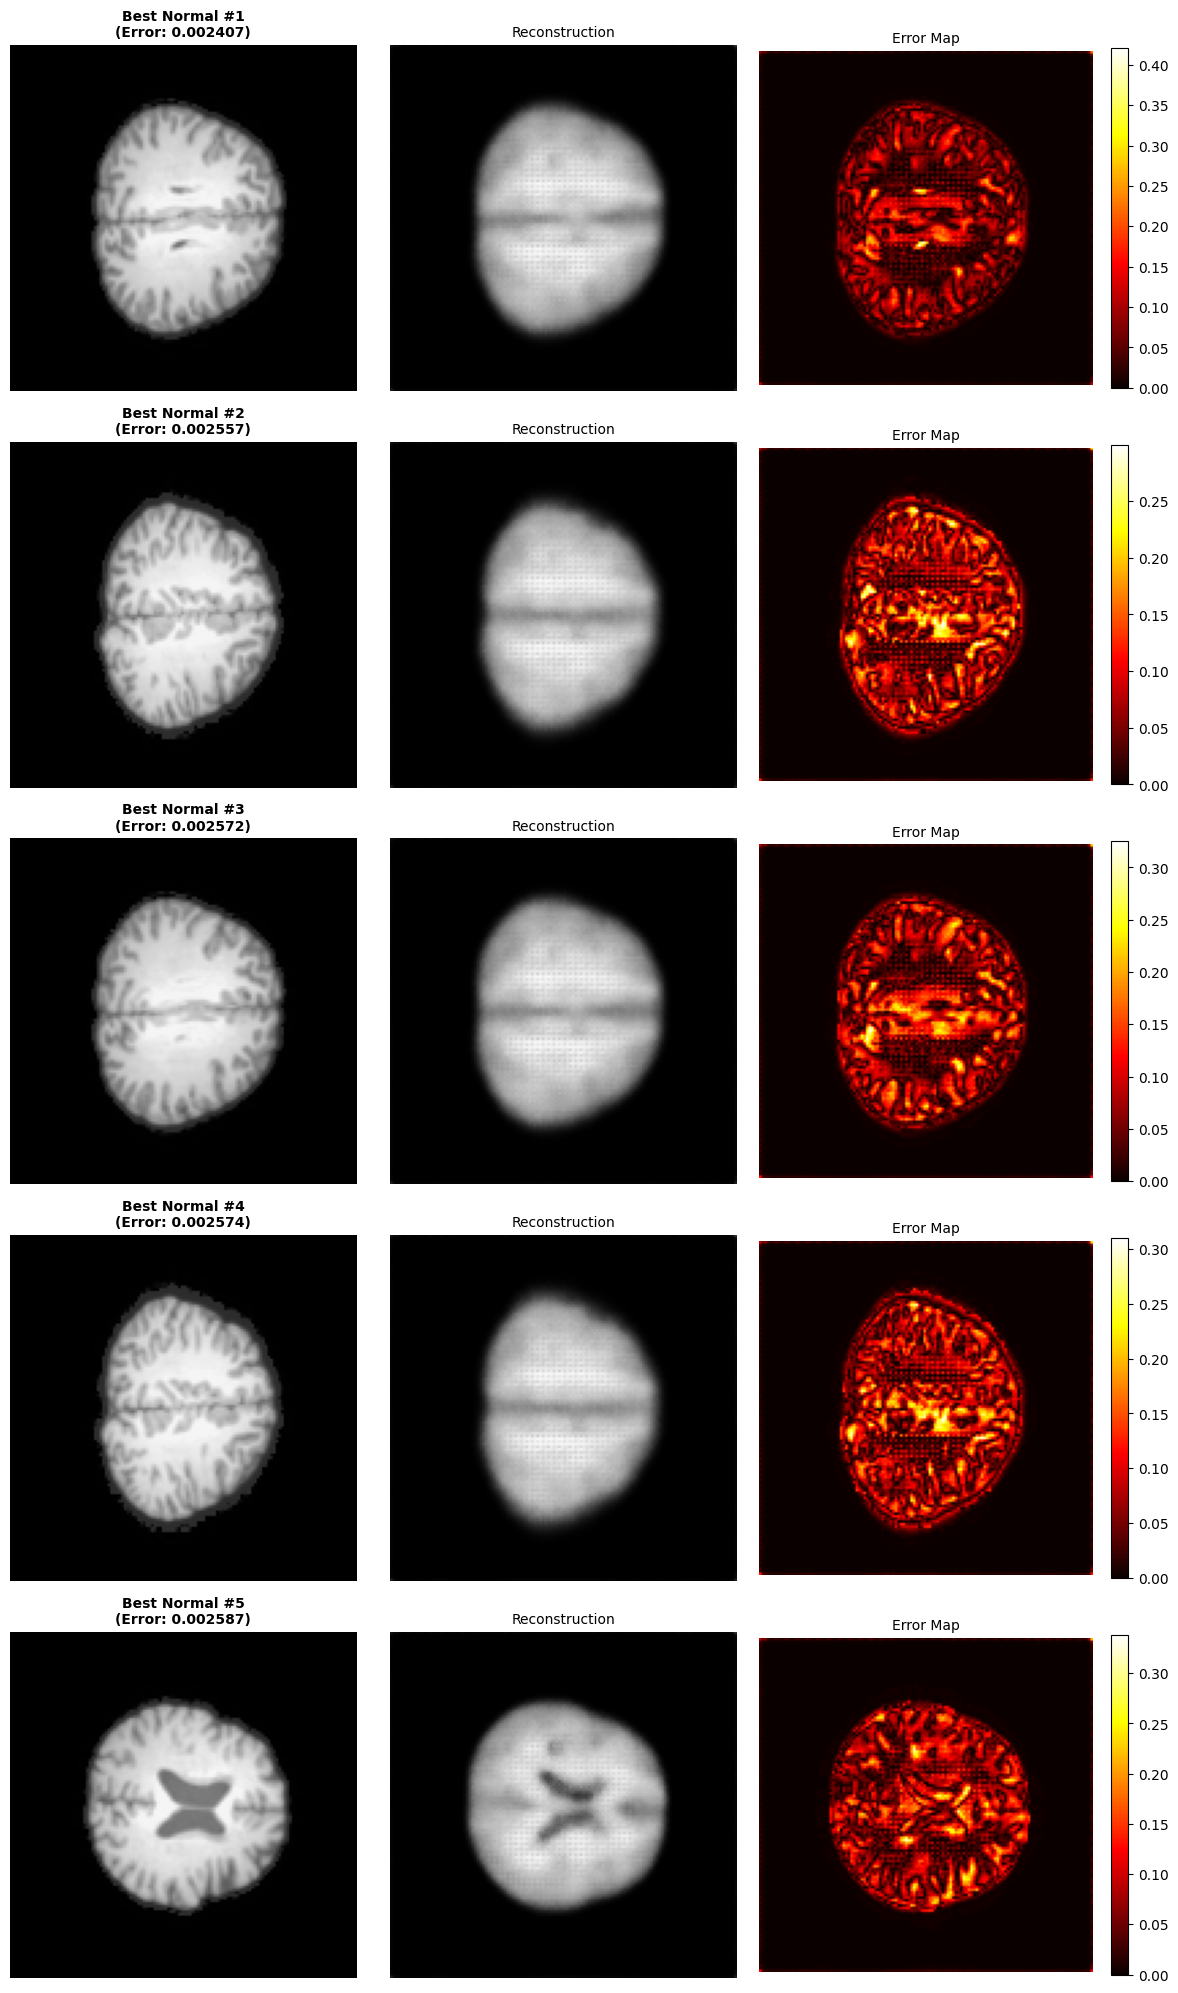


🚨 Visualizing Top 5 Most Obvious Tumors...


<Figure size 640x480 with 0 Axes>

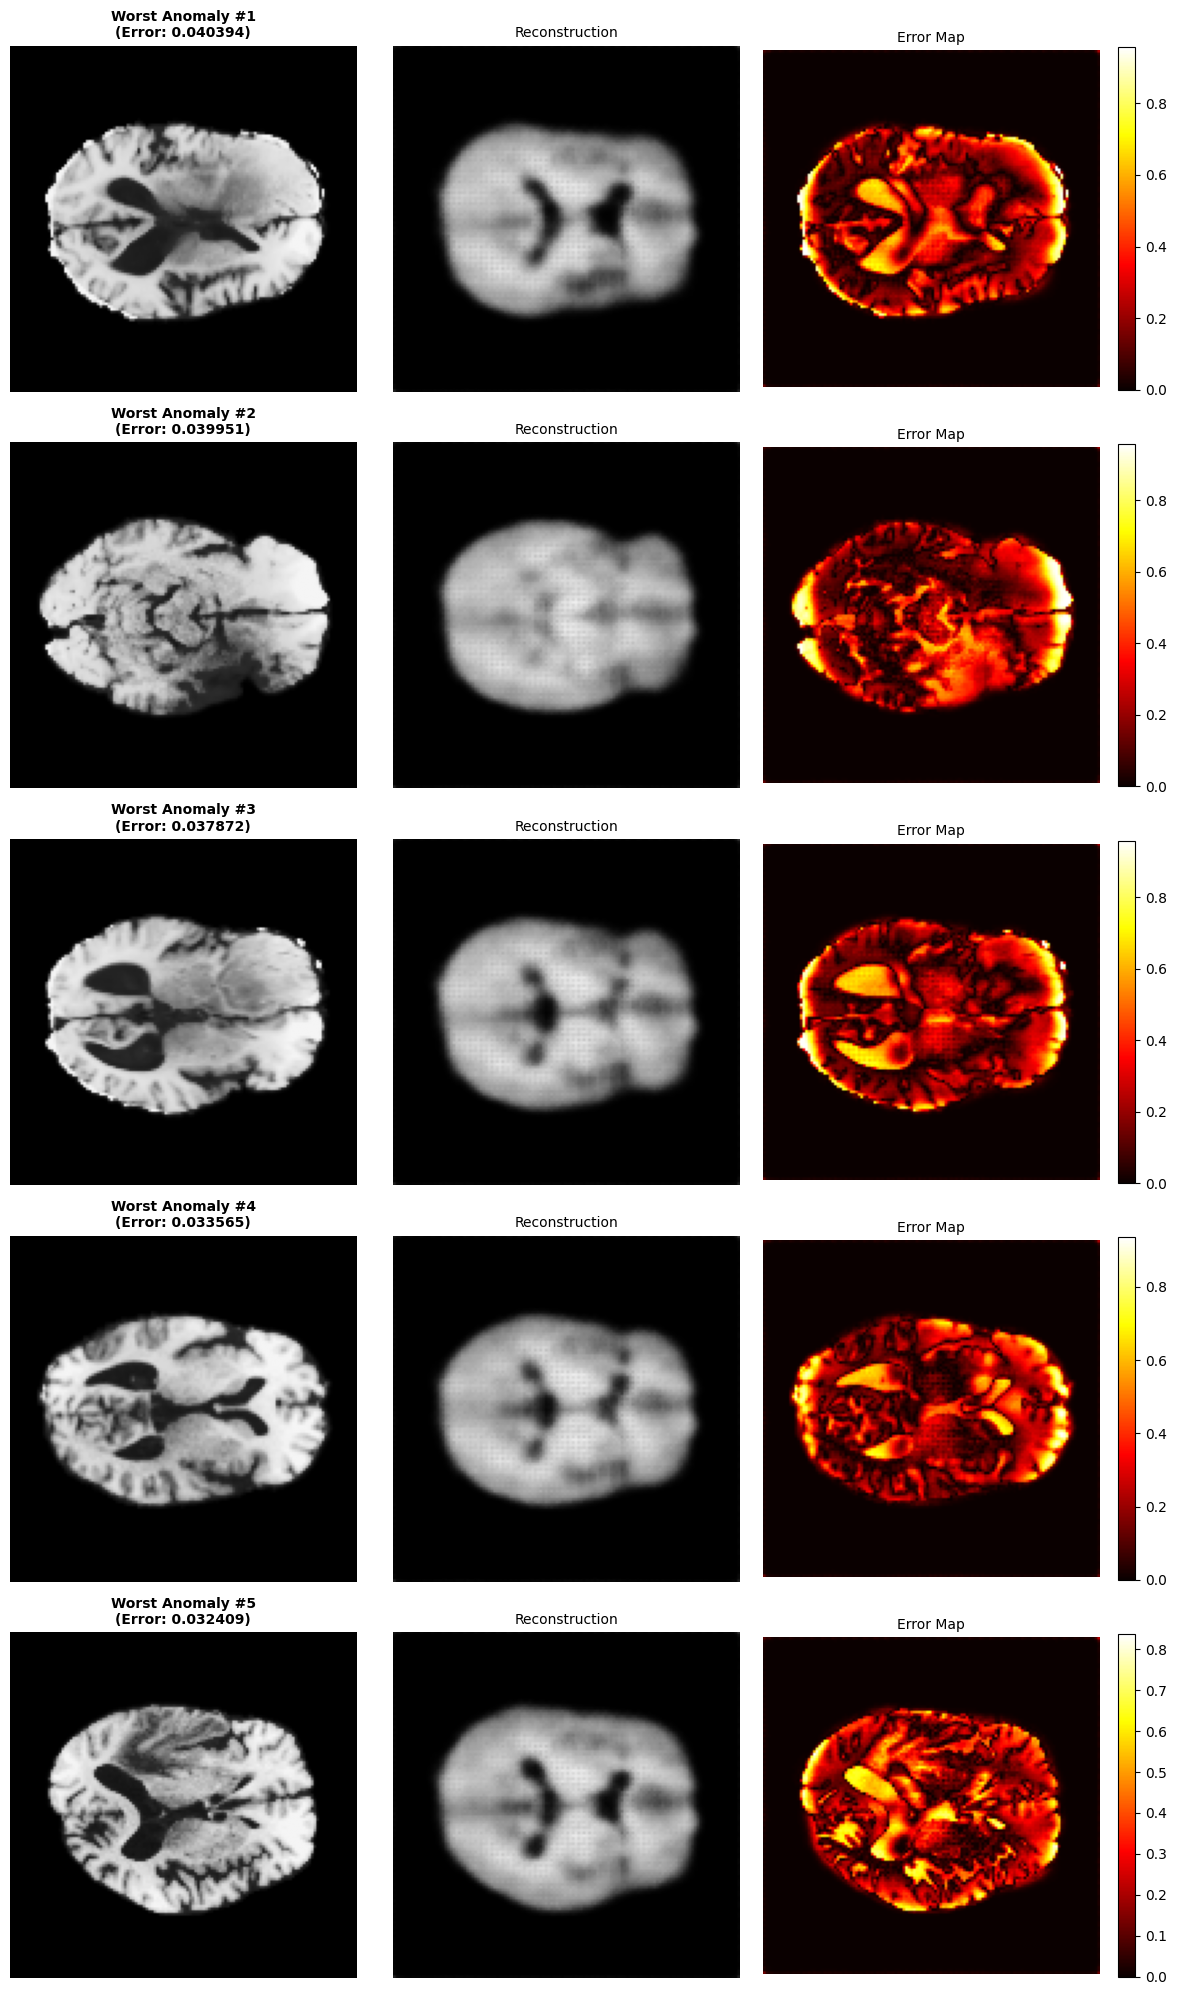

✅ Extreme case visualizations saved to /content/drive/MyDrive/symAD-ECNN/results/resnet_finetuned_partial


<Figure size 640x480 with 0 Axes>

In [22]:
# ==========================================
# 🔍 VISUALIZE HISTOGRAM EXTREMES (Non-Overlapping)
# ==========================================
def plot_extremes(model, dataset, indices, errors, title_prefix):
    """
    Plots the specific indices provided (Best Normals or Worst Anomalies)
    """
    model.eval()
    plt.figure(figsize=(12, 4 * len(indices)))

    for i, idx in enumerate(indices):
        # 1. Get Data
        input_tensor, target_tensor = dataset[idx]
        input_tensor = input_tensor.unsqueeze(0).to(device)

        # 2. Reconstruct
        with torch.no_grad():
            recon = model(input_tensor)

        # 3. Process
        target_np = target_tensor.squeeze().numpy()
        recon_np = recon.cpu().squeeze().numpy()
        error_np = np.abs(target_np - recon_np)

        # 4. Plot
        plt.subplot(len(indices), 3, i*3 + 1)
        plt.imshow(target_np, cmap='gray', vmin=0, vmax=1)
        plt.title(f"{title_prefix} #{i+1}\n(Error: {errors[idx]:.6f})", fontsize=10, fontweight='bold')
        plt.axis('off')

        plt.subplot(len(indices), 3, i*3 + 2)
        plt.imshow(recon_np, cmap='gray', vmin=0, vmax=1)
        plt.title("Reconstruction", fontsize=10)
        plt.axis('off')

        plt.subplot(len(indices), 3, i*3 + 3)
        im = plt.imshow(error_np, cmap='hot', vmin=0, vmax=error_np.max())
        plt.title("Error Map", fontsize=10)
        plt.axis('off')
        plt.colorbar(im, fraction=0.046)

    plt.tight_layout()
    # Save automatically
    plt.savefig(f'{RESULTS_PATH}/resnet_finetuned_extremes_{title_prefix.lower().replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

# --- FIND INDICES ---
sorted_normal_indices = np.argsort(normal_errors)
best_normal_indices = sorted_normal_indices[:5]

sorted_anomaly_indices = np.argsort(anomaly_errors)
worst_anomaly_indices = sorted_anomaly_indices[-5:][::-1]

# --- PLOT & SAVE ---
print(f"🌟 Visualizing Top 5 Best Healthy Brains...")
fig = plot_extremes(model, val_dataset, best_normal_indices, normal_errors, "Best Normal")
plt.savefig(f'{RESULTS_PATH}/resnet_ae_ft_extremes_best_normal.png', dpi=150, bbox_inches='tight')

print(f"\n🚨 Visualizing Top 5 Most Obvious Tumors...")
fig2 = plot_extremes(model, test_dataset, worst_anomaly_indices, anomaly_errors, "Worst Anomaly")
plt.savefig(f'{RESULTS_PATH}/resnet_ae_ft_extremes_worst_anomaly.png', dpi=150, bbox_inches='tight')

print(f"✅ Extreme case visualizations saved to {RESULTS_PATH}")

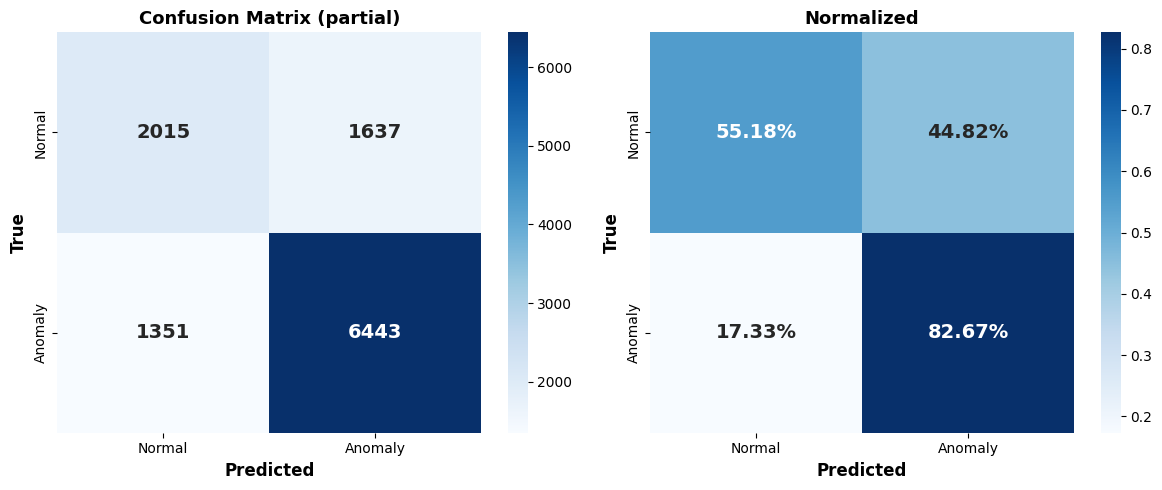


📊 Classification Metrics:
   Accuracy:    0.7389
   Precision:   0.7974
   Recall:      0.8267
   Specificity: 0.5518
   F1-Score:    0.8118


In [23]:
# Confusion Matrix
import seaborn as sns

# Optimal threshold
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

predictions = (y_scores > optimal_threshold).astype(int)
cm = confusion_matrix(y_true, predictions)

# Calculate metrics
tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1 = 2 * (precision_val * recall_val) / (precision_val + recall_val) if (precision_val + recall_val) > 0 else 0

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_xlabel('Predicted', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True', fontsize=12, fontweight='bold')
axes[0].set_title(f'Confusion Matrix ({FINETUNE_STRATEGY})', fontsize=13, fontweight='bold')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Normal', 'Anomaly'], yticklabels=['Normal', 'Anomaly'],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[1].set_xlabel('Predicted', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True', fontsize=12, fontweight='bold')
axes[1].set_title('Normalized', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/resnet_finetuned_confusion_matrix.png', dpi=150)
plt.show()

print(f"\n📊 Classification Metrics:")
print(f"   Accuracy:    {accuracy:.4f}")
print(f"   Precision:   {precision_val:.4f}")
print(f"   Recall:      {recall_val:.4f}")
print(f"   Specificity: {specificity:.4f}")
print(f"   F1-Score:    {f1:.4f}")

In [24]:
# Save results
results = {
    'model': f'ResNet-18 Autoencoder (Fine-tuned: {FINETUNE_STRATEGY})',
    'finetune_strategy': FINETUNE_STRATEGY,
    'auroc': float(auroc),
    'auprc': float(auprc),
    'accuracy': float(accuracy),
    'precision': float(precision_val),
    'recall': float(recall_val),
    'specificity': float(specificity),
    'f1_score': float(f1),
    'optimal_threshold': float(optimal_threshold),
    'best_epoch': best_epoch,
    'best_val_loss': float(best_val_loss),
    'normal_error_mean': float(normal_errors.mean()),
    'anomaly_error_mean': float(anomaly_errors.mean()),
    'total_params': total_params,
    'trainable_params': trainable_params,
    'encoder_trainable_params': encoder_trainable,
    'decoder_trainable_params': decoder_trainable,
    'training_time_hours': total_time / 3600,
    'confusion_matrix': {'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn)}
}

with open(f'{RESULTS_PATH}/resnet_finetuned_results.json', 'w') as f:
    json.dump(results, f, indent=4)

print("\n✅ ResNet-AE (Fine-tuned) evaluation complete!")
print(f"   Results saved to {RESULTS_PATH}/resnet_finetuned_results.json")


✅ ResNet-AE (Fine-tuned) evaluation complete!
   Results saved to /content/drive/MyDrive/symAD-ECNN/results/resnet_finetuned_partial/resnet_finetuned_results.json


## 8️⃣ Final Summary

In [25]:
print("\n" + "="*70)
print(f"🎉 RESNET-AUTOENCODER ({FINETUNE_STRATEGY.upper()}) COMPLETE!")
print("="*70)
print(f"\n📊 Performance:")
print(f"   AUROC:       {auroc:.4f}")
print(f"   AUPRC:       {auprc:.4f}")
print(f"   Accuracy:    {accuracy:.4f}")
print(f"   Recall:      {recall_val:.4f}")
print(f"   Specificity: {specificity:.4f}")
print(f"\n⏱️ Training:")
print(f"   Total Time:  {total_time/60:.1f} minutes")
print(f"   Best Epoch:  {best_epoch}/{NUM_EPOCHS}")
print(f"\n🔧 Architecture:")
print(f"   Fine-tuning: {FINETUNE_STRATEGY.upper()}")
print(f"   Encoder:     ResNet-18 (pretrained + fine-tuned)")
print(f"   Decoder:     CNN (trained)")
print(f"   Total params: {total_params:,}")
print(f"   Trained:     {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")
print(f"   └─ Encoder:  {encoder_trainable:,}")
print(f"   └─ Decoder:  {decoder_trainable:,}")
print("\n" + "="*70)
print("📝 KEY INSIGHT:")
if FINETUNE_STRATEGY == 'partial':
    print("   Partial fine-tuning adapts high-level features to MRI")
    print("   while preserving robust low-level ImageNet features.")
elif FINETUNE_STRATEGY == 'full':
    print("   Full fine-tuning maximally adapts all ResNet layers")
    print("   to the medical imaging domain.")
else:
    print("   No fine-tuning - pure transfer learning baseline.")
print("="*70)


🎉 RESNET-AUTOENCODER (PARTIAL) COMPLETE!

📊 Performance:
   AUROC:       0.7398
   AUPRC:       0.8355
   Accuracy:    0.7389
   Recall:      0.8267
   Specificity: 0.5518

⏱️ Training:
   Total Time:  60.9 minutes
   Best Epoch:  38/40

🔧 Architecture:
   Fine-tuning: PARTIAL
   Encoder:     ResNet-18 (pretrained + fine-tuned)
   Decoder:     CNN (trained)
   Total params: 18,159,585
   Trained:     15,376,801 (84.7%)
   └─ Encoder:  8,393,728
   └─ Decoder:  6,983,073

📝 KEY INSIGHT:
   Partial fine-tuning adapts high-level features to MRI
   while preserving robust low-level ImageNet features.


In [26]:
print("Confusion Matrix Breakdown:")
print(f"   True Positives (TP): {tp}")
print(f"   True Negatives (TN): {tn}")
print(f"   False Positives (FP): {fp}")
print(f"   False Negatives (FN): {fn}")

Confusion Matrix Breakdown:
   True Positives (TP): 6443
   True Negatives (TN): 2015
   False Positives (FP): 1637
   False Negatives (FN): 1351
